In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
!pip install torch torchvision torchaudio --quiet


In [ ]:
!unzip -qq dataset.zip

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content

dataset.zip  sample_data


In [ ]:
!unzip /content/dataset.zip -d /content/

Archive:  /content/dataset.zip
   creating: /content/data/
   creating: /content/data/Betel/
  inflating: /content/data/Betel/__0_1506402.png  
  inflating: /content/data/Betel/__0_2353287.png  
  inflating: /content/data/Betel/__0_2529593.png  
  inflating: /content/data/Betel/__0_3089470.png  
  inflating: /content/data/Betel/__0_3360397.png  
  inflating: /content/data/Betel/__0_5170086.png  
  inflating: /content/data/Betel/__0_5592889.png  
  inflating: /content/data/Betel/__0_6425534.png  
  inflating: /content/data/Betel/__0_6689299.png  
  inflating: /content/data/Betel/__0_8571978.png  
  inflating: /content/data/Betel/__10_2731722.png  
  inflating: /content/data/Betel/__10_3966653.png  
  inflating: /content/data/Betel/__10_4914416.png  
  inflating: /content/data/Betel/__10_5415879.png  
  inflating: /content/data/Betel/__10_6628944.png  
  inflating: /content/data/Betel/__10_6673181.png  
  inflating: /content/data/Betel/__10_7909513.png  
  inflating: /content/data/Betel/

In [ ]:
!ls /content

data  dataset.zip  sample_data


FINAL CODE

Using device: cuda
Classes: ['Betel', 'Guava', 'Hibiscus', 'Jasmine', 'Mango', 'Mint', 'Neem', 'Pomegranate', 'Sandalwood', 'Tulsi']
Total images: 4910
Training images: 3928
Testing images: 982
Training Started...

Epoch [10/10]
------ TRAINING RESULTS ------
Training Loss     : 0.0728
Training Accuracy : 97.71%
------ TESTING RESULTS -------
Testing Loss       : 0.1094
Testing Accuracy   : 96.74%
------ METRICS ---------------
F1 Score   : 0.9678
Precision  : 0.9702
Recall     : 0.9674

===== ADVANCED METRICS =====
F1 Score: 0.9678
Precision: 0.9702
Recall: 0.9674

Classification Report:
              precision    recall  f1-score   support

       Betel       1.00      0.90      0.95       113
       Guava       1.00      0.97      0.98       118
    Hibiscus       0.85      1.00      0.92        76
     Jasmine       0.92      0.95      0.94       109
       Mango       1.00      0.96      0.98        94
        Mint       0.99      0.99      0.99        79
        Neem       1.00  

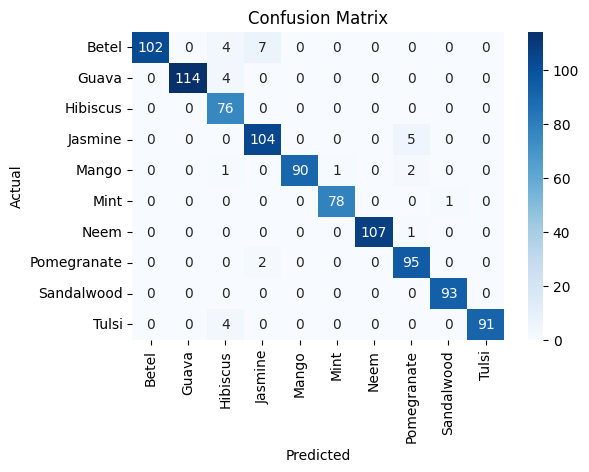

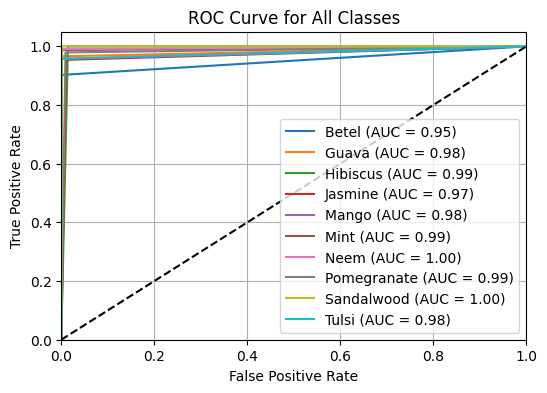


Model saved at: /content/model.pth


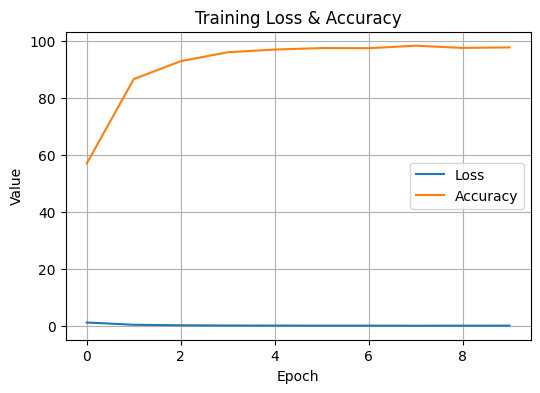

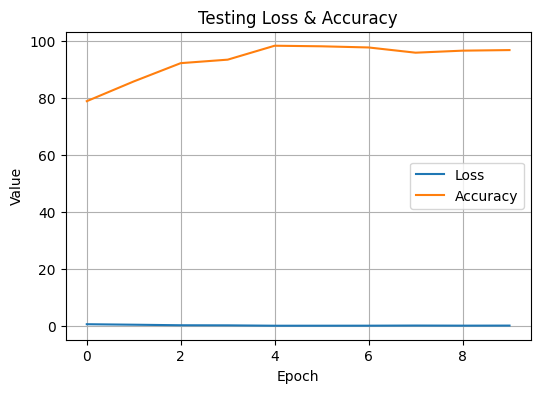

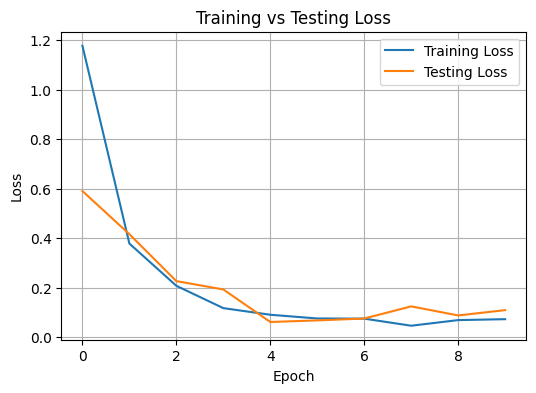

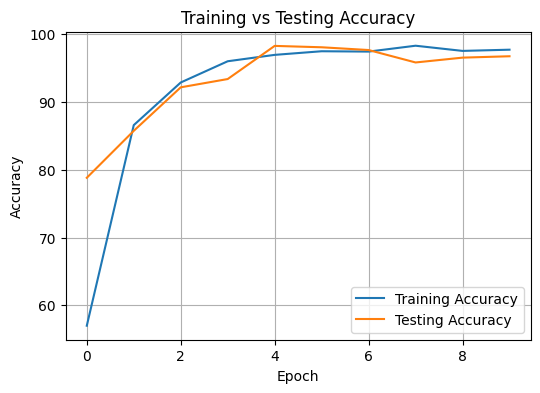

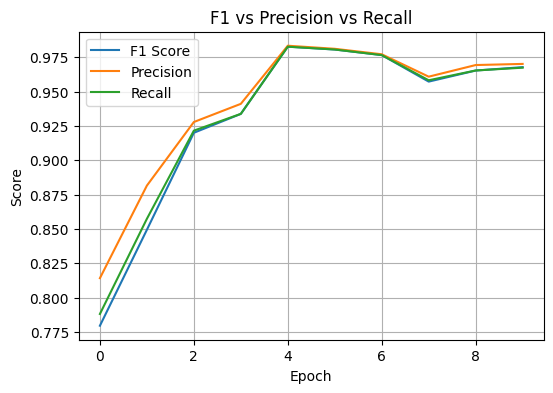


================ FINAL RESULT ================
Final Training Accuracy : 97.71%
Final Testing Accuracy  : 96.74%


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# -------------------------
# CONFIG
# -------------------------
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 0.0003
DATASET_PATH = "/content/data"
MODEL_PATH = "/content/model.pth"

# DEVICE
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -------------------------
# TRANSFORMS
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE + 32),
    transforms.RandomResizedCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE + 32),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# -------------------------
# LOAD DATASET
# -------------------------
full_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)

# 80/20 Split
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
test_dataset.dataset.transform = test_transform
print("Total images:", len(full_dataset))
print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# MODEL – Vision Transformer
# -------------------------
import torchvision.models as models

model = models.vit_b_16(weights="DEFAULT")
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# -------------------------
# TRAIN
# -------------------------
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
f1_scores = []
precisions = []
recalls = []

print("Training Started...\n")

for epoch in range(EPOCHS):

    # ===== TRAINING =====
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = epoch_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # ===== TESTING =====
    model.eval()
    test_correct = 0
    test_total = 0
    test_loss = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * test_correct / test_total

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
    precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)

    f1_scores.append(f1)
    precisions.append(precision)
    recalls.append(recall)

print(f"Epoch [{epoch+1}/{EPOCHS}]")

print("------ TRAINING RESULTS ------")
print(f"Training Loss     : {train_loss:.4f}")
print(f"Training Accuracy : {train_accuracy:.2f}%")

print("------ TESTING RESULTS -------")
print(f"Testing Loss       : {test_loss:.4f}")
print(f"Testing Accuracy   : {test_accuracy:.2f}%")

print("------ METRICS ---------------")
print(f"F1 Score   : {f1:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print("="*40)

# =========================
# EXTRA METRICS (F1, PRECISION, RECALL, CONFUSION MATRIX)
# =========================

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# ----- METRICS -----
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

print("\n===== ADVANCED METRICS =====")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))

# ----- CONFUSION MATRIX -----
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# ROC & AUC CURVE (Multi-class)
# ===============================

# Binarize the labels for ROC
y_test = label_binarize(all_labels, classes=range(num_classes))
y_pred = label_binarize(all_predictions, classes=range(num_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC Curve
plt.figure(figsize=(6, 4))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for All Classes")
plt.legend(loc="lower right")
plt.grid()
plt.show()

print("============================\n")

# -------------------------
# SAVE MODEL FOR predict.py
# -------------------------
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": class_names
}, MODEL_PATH)

print(f"Model saved at: {MODEL_PATH}")

# -------------------------
# PLOT LOSS & ACCURACY
# -------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Loss")
plt.plot(train_accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Loss & Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(test_losses, label="Loss")
plt.plot(test_accuracies, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Testing Loss & Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(test_accuracies, label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(f1_scores, label="F1 Score")
plt.plot(precisions, label="Precision")
plt.plot(recalls, label="Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("F1 vs Precision vs Recall")
plt.legend()
plt.grid()
plt.show()

print("\n================ FINAL RESULT ================")
print(f"Final Training Accuracy : {train_accuracies[-1]:.2f}%")
print(f"Final Testing Accuracy  : {test_accuracies[-1]:.2f}%")
print("================================================")
